## 1 - Packages

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from public_tests_a1 import * 

tf.keras.backend.set_floatx('float64')
from assigment_utils import *

tf.autograph.set_verbosity(0)

## 2 - Evaluavting a Learning Algoirthm (polynomial Regression)
### 2.1 Splitting Data

In [2]:
# Generate some data
X,y,x_ideal,y_ideal = gen_data(18, 2, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

# split the data using skicit learn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (18,) y.shape (18,)
X_train.shape (12,) y_train.shape (12,)
X_test.shape (6,) y_test.shape (6,)


## 2.2 Plot Test, Train Data

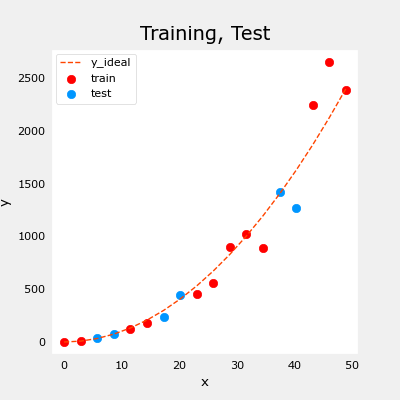

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot(x_ideal, y_ideal, '--', color = "orangered", label='y_ideal', lw=1)
ax.set_title("Training, Test", fontsize=14)
ax.set_ylabel('y')
ax.set_xlabel('x')

ax.scatter(X_train, y_train, color='red', label='train')
ax.scatter(X_test, y_test, color = dlc["dlblue"], label = "test")
ax.legend(loc='upper left')
plt.show()

## 2.2 Error Calculation for Model Evaluation, Linear Regression
create a function to evaluate the error on a data set for a linear regression model

In [4]:
def eval_mse(y, yhat):
    """ 
    Calculate the mean squared error on a data set.
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:
      err: (scalar)             
    """
    m = len(y)
    error = 0.0

    for i in range(m):
        error += (yhat[i] - y[i]) ** 2

    return error / (2 * m)

In [5]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
eval_mse(y_hat, y_tmp)

# BEGIN UNIT TEST
test_eval_mse(eval_mse)   
# END UNIT TEST

 All tests passed.


## 2.3 Compare Performance on Training and Test Data

In [6]:
degree = 10

poly = PolynomialFeatures(degree, include_bias=False)
X_train_mapped = poly.fit_transform(X_train.reshape(-1,1))
X_test_mapped = poly.transform(X_test.reshape(-1,1))

scalar_poly = StandardScaler()
X_train_mapped_scaled = scalar_poly.fit_transform(X_train_mapped)
X_test_mapped_scaled = scalar_poly.transform(X_test_mapped)

model = LinearRegression()
model.fit(X_train_mapped_scaled, y_train)

yhat_train = model.predict(X_train_mapped_scaled)
yhat_test = model.predict(X_test_mapped_scaled)

err_train = mean_squared_error(yhat_train, y_train) / 2
err_test = mean_squared_error(yhat_test, y_test) / 2

In [7]:
print(f"training err {err_train:0.2f}, test err {err_test:0.2f}")

training err 58.01, test err 171215.01


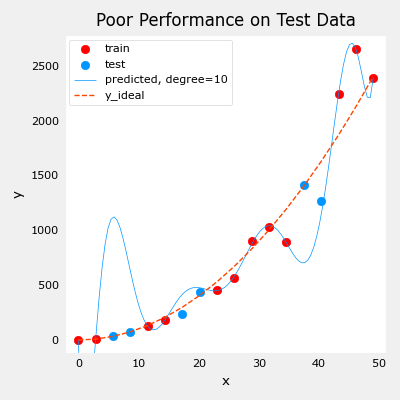

In [8]:
# plot predictions over data range 
degree = 10
lmodel = lin_model(degree)
lmodel.fit(X_train, y_train)
x = np.linspace(0,int(X.max()),100)  # predict values for plot
y_pred = lmodel.predict(x).reshape(-1,1)

plt_train_test(X_train, y_train, X_test, y_test, x, y_pred, x_ideal, y_ideal, degree)

## Bias and Variance
Generate train, cross validation, and train

In [9]:
# Generate  data
X,y, x_ideal,y_ideal = gen_data(40, 5, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

# split the data
X_train, X_, y_train, y_ = train_test_split(X, y, test_size = 0.40, random_state = 1)
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size = 0.50, random_state = 1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (40,) y.shape (40,)
X_train.shape (24,) y_train.shape (24,)
X_cv.shape (8,) y_cv.shape (8,)
X_test.shape (8,) y_test.shape (8,)


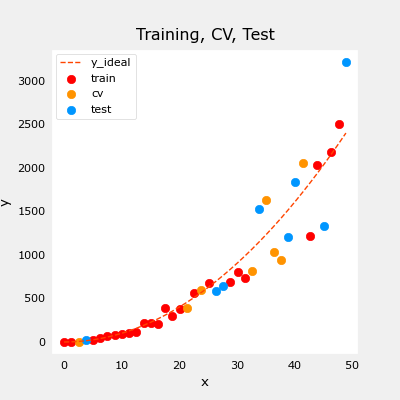

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot(x_ideal, y_ideal, '--', color = 'orangered', label = 'y_ideal', lw=1)
ax.set_title("Training, CV, Test")
ax.set_ylabel('y')
ax.set_xlabel('x')

ax.scatter(X_train, y_train, color = 'red', label='train')
ax.scatter(X_cv, y_cv,       color = dlc["dlorange"], label="cv")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

In [11]:
max_degree = 9
err_train = np.zeros(max_degree)    
err_cv = np.zeros(max_degree)      
x = np.linspace(0,int(X.max()),100)  
y_pred = np.zeros((100,max_degree))  #columns are lines to plot

for degree in range(max_degree):
    lmodel = lin_model(degree+1)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[degree] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[degree] = lmodel.mse(y_cv, yhat)
    y_pred[:,degree] = lmodel.predict(x)
    
optimal_degree = np.argmin(err_cv)+1

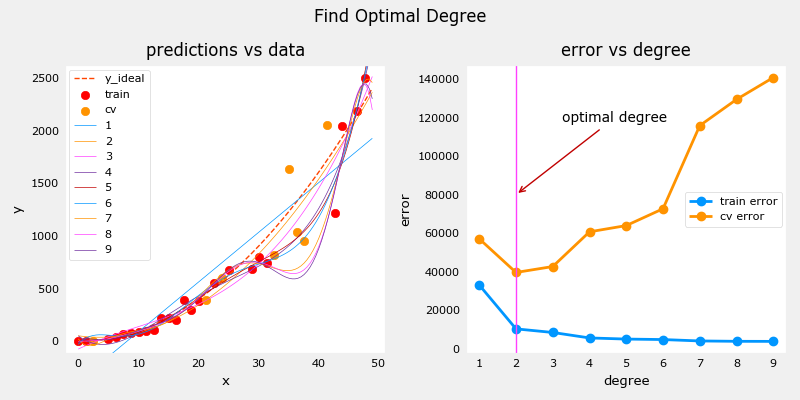

In [12]:
plt.close("all")
plt_optimal_degree(X_train, y_train, X_cv, y_cv, x, y_pred, x_ideal, y_ideal, 
                   err_train, err_cv, optimal_degree, max_degree)

In [13]:
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)    
err_cv = np.zeros(num_steps)       
x = np.linspace(0,int(X.max()),100) 
y_pred = np.zeros((100,num_steps))  #columns are lines to plot

for i in range(num_steps):
    lambda_= lambda_range[i]
    lmodel = lin_model(degree, regularization=True, lambda_=lambda_)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[i] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[i] = lmodel.mse(y_cv, yhat)
    y_pred[:,i] = lmodel.predict(x)
    
optimal_reg_idx = np.argmin(err_cv)

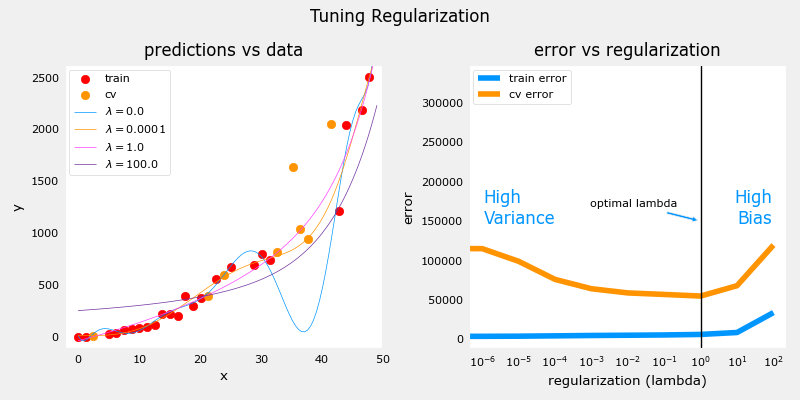

In [14]:
plt.close("all")
plt_tune_regularization(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, optimal_reg_idx, lambda_range)

## Getting more data: increasing training set size 

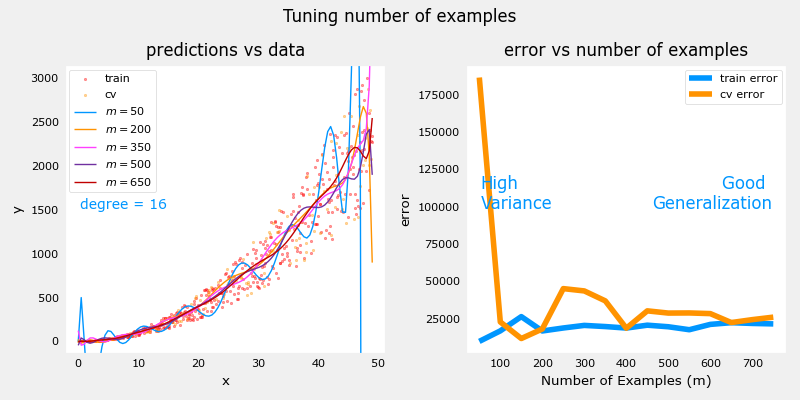

In [15]:
X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range,degree = tune_m()
plt_tune_m(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree)

# 4 - Evaluating a Learning Algorithm (Neural Network)

## 4.1 Data Set

In [17]:
# Generate and split data set
X, y, centers, classes, std = gen_blobs()

# split the data, large CV population for demonstartion
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.5, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.2, random_state=1)
print("X_train.shape:", X_train.shape, "X_cv.shape:", X_cv.shape, "X_test.shape:", X_test.shape)


X_train.shape: (400, 2) X_cv.shape: (320, 2) X_test.shape: (80, 2)


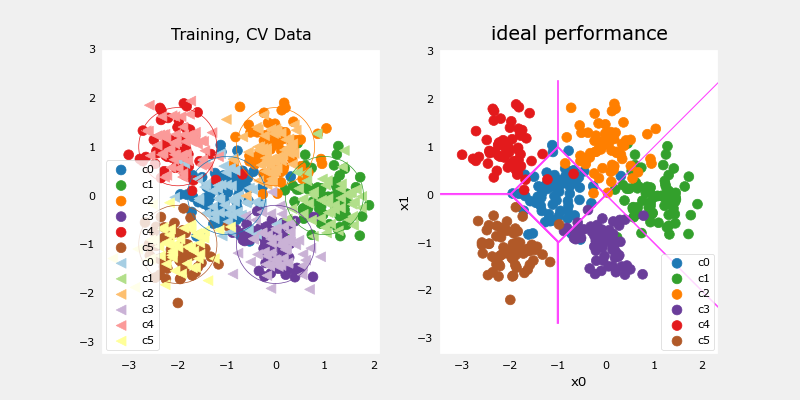

In [18]:
plt_train_eq_dist(X_train, y_train,classes, X_cv, y_cv, centers, std)

## 4.2 Evaluating categorical model by calculating classification error
The evaluation function for categorical models used here is simply the fraction of incorrect predictions:
$$ J_{cv} = \frac{1}{m} \Sigma^{m-1}_{i=0} \left\{ \begin{aligned} 
1, \text{if } \hat{y^{(i)}} \neq y^{(i)} \\
  0, \text{ otherwise}
\end{aligned} \right. $$

In [19]:
def eval_cat_err(y, yhat):
    """ 
    Calculate the categorization error
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:|
      cerr: (scalar)             
    """
    m = len(y)
    err = 0.0

    for i in range(m):
        if yhat[i] != y[i]:
            err += 1

    return err/m

In [20]:
y_hat = np.array([1, 2, 0])
y_tmp = np.array([1, 2, 3])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.333" )
y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.250" )

# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST
# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST

categorization error 0.333, expected:0.333
categorization error 0.250, expected:0.250
 All tests passed.
 All tests passed.


# 5 - Model Complexity
Building two models. A complex model and a simple model. Evaluate the models to determine if they are likely to overfit or underfit
## 5.1 Complex Model


In [21]:
X_train.shape

(400, 2)

In [24]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.random.set_seed(1234)

model = Sequential(
    [
        tf.keras.Input((2,)),
        tf.keras.layers.Dense(120, activation='relu'),
        tf.keras.layers.Dense(40, activation='relu'),
        tf.keras.layers.Dense(6, activation='linear')
    ], name="complex")

model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

model.fit(
    X_train, 
    y_train,
    epochs = 1000)

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.3730
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4360  
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3366
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2682
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2290
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2208
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2143
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2034  
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1995
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1985
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1944
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1921 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1930
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1872  
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/st

In [25]:
model.summary()

Model: "complex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 120)                 │             360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 40)                  │           4,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 6)                   │             246 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,340 (127.66 KB)

 Trainable params: 5,446 (42.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (85.11 KB)

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


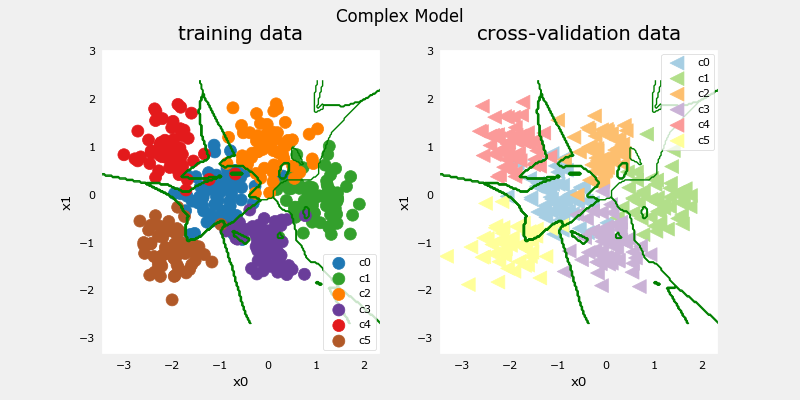

In [26]:
#make a model for plotting routines to call
model_predict = lambda Xl: np.argmax(tf.nn.softmax(model.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict,X_train,y_train, classes, X_cv, y_cv, suptitle="Complex Model")

In [27]:
training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
categorization error, training, complex model: 0.015
categorization error, cv,       complex model: 0.109


## 5.1 Simple Model

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)


tf.random.set_seed(1234)
model_s = Sequential(
    [
        tf.keras.Input((2,)),
        tf.keras.layers.Dense(6, activation='relu'),
        tf.keras.layers.Dense(6, activation = 'linear'),
    ], name='simple')

model_s.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
)

model_s.fit(X_train, y_train, epochs=1000)

In [30]:
model_s.summary()

Model: "simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 6)                   │              18 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 6)                   │              42 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 182 (1.42 KB)

 Trainable params: 60 (480.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 122 (976.00 B)

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


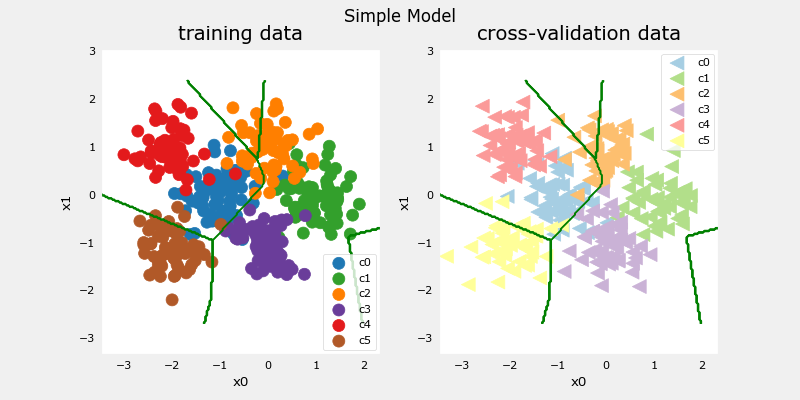

In [34]:
model_predict_s = lambda Xl: np.argmax(tf.nn.softmax(model_s.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict_s,X_train,y_train, classes, X_cv, y_cv, suptitle="Simple Model")

In [35]:
training_cerr_simple = eval_cat_err(y_train, model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv, model_predict_s(X_cv))
print(f"categorization error, training, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
categorization error, training, simple model, 0.505, complex model: 0.015
categorization error, cv,       simple model, 0.466, complex model: 0.109


# 6 - Regularization

In [42]:
tf.random.set_seed(1234)
model_r = Sequential(
    [
        tf.keras.Input((2, )),
        tf.keras.layers.Dense(120, activation='relu', kernel_regularizer= tf.keras.regularizers.l2(0.1)),
        tf.keras.layers.Dense(40, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.1)),
        tf.keras.layers.Dense(6, activation='linear')
    ], name=None)

model_r.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01))


In [43]:
# BEGIN UNIT TEST
model_r.fit(
    X_train, y_train,
    epochs=1000
)
# END UNIT TEST

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5.7711
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7059  
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3401
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1130 
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0112  
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9556
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9049 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8682
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8353  
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7979  
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7667  
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7424  
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7297
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7181 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0

# 7 - Iterate to find optimal regularization value

In [ ]:
tf.random.set_seed(1234)
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
models=[None] * len(lambdas)
for i in range(len(lambdas)):
    lambda_ = lambdas[i]
    models[i] =  Sequential(
        [
            Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(classes, activation = 'linear')
        ]
    )
    models[i].compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.01),
    )

    models[i].fit(
        X_train,y_train,
        epochs=1000
    )
    print(f"Finished lambda = {lambda_}")